In [1]:
#imports
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import mpl_axes_aligner

In [2]:
# Open the data
df = pd.read_csv('data/vwodata.csv')
print(df.head())
print(df.columns)
# Extract features
features = df.columns[1:]  # Assuming first column is an identifier

x = df.loc[:, features].values  

# Standardize the data
aantal_features = len(features)
print(f"Aantal features: {aantal_features}")

      NL     Fr     Du     En     Ge     Ak   WkAC   WkBD     Nk     Sk  \
0  74.69  79.21  70.98  71.60  72.52  71.26  67.39  76.09  64.86  72.33   
1  70.19  75.60  72.59  72.10  72.92  66.85  63.95  76.45  76.07  70.29   
2  71.07  71.87  66.44  66.69  63.30  56.64  63.88  61.90  68.97  68.54   
3  66.86  65.28  56.97  65.12  67.03  67.78  66.90  75.28  65.74  67.20   
4  67.67  65.56  65.67  67.24  66.58  71.54  67.51  66.78  64.65  63.50   

      Bi     Ec  
0  67.81  75.07  
1  68.24  76.92  
2  63.84  62.62  
3  68.62  61.72  
4  68.95  64.78  
Index(['NL', 'Fr', 'Du', 'En', 'Ge', 'Ak', 'WkAC', 'WkBD', 'Nk', 'Sk', 'Bi',
       'Ec'],
      dtype='object')
Aantal features: 11


In [3]:
# PCA: Scree plot
pca = PCA()  
pca_out = pca.fit_transform(df)
print(pca.explained_variance_ratio_)




[0.21846319 0.1540947  0.10497017 0.0952543  0.08825434 0.07723311
 0.07180433 0.06790479 0.04323707 0.04088504 0.03621695 0.001682  ]


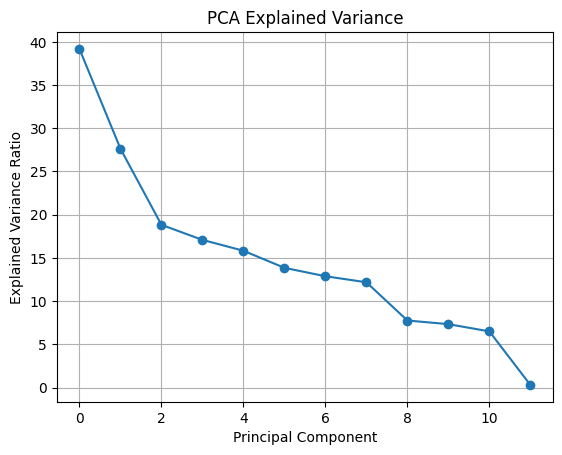

In [7]:
plt.plot(pca.explained_variance_, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance')
plt.grid()
plt.show()

In [8]:
# Print(summary (explained variance ratio))
print(pd.DataFrame({
   'Explained Variance Ratio': pca.explained_variance_ratio_,
   'Cumulative Explained Variance': pca.explained_variance_ratio_.cumsum()
}))

    Explained Variance Ratio  Cumulative Explained Variance
0                   0.218463                       0.218463
1                   0.154095                       0.372558
2                   0.104970                       0.477528
3                   0.095254                       0.572782
4                   0.088254                       0.661037
5                   0.077233                       0.738270
6                   0.071804                       0.810074
7                   0.067905                       0.877979
8                   0.043237                       0.921216
9                   0.040885                       0.962101
10                  0.036217                       0.998318
11                  0.001682                       1.000000


In [9]:
# Biplot function: Needs scores, loadings and pca (for variances)
def biplot(dfScores: pd.DataFrame, dfLoadings: pd.DataFrame, pca) -> None:
    
    # create figure and axis objects
    fig,ax = plt.subplots(figsize=(6,6))
    
    # plot the "scores" (pca coordinates for rows) 
    ax.scatter(dfScores.PC1.values,dfScores.PC2.values, s=5, color='b')  # s = size
   
    # we add explained variance in % to the axes
    explvar = 100 * pca.explained_variance_ratio_
    #set x-axis label
    ax.set_xlabel(f"PC1 ({explvar[0]:.1f}% explained var.)",fontsize=10)
    #set y-axis label
    ax.set_ylabel(f"PC2 ({explvar[1]:.1f}% explained var.)",fontsize=10)
        
    # create a second set of axes. That is: the plotting of the columns
    ax2 = ax.twinx().twiny()
    
    #setup font dictionary
    font = {'color':  'g',
            'weight': 'bold',
            'size': 12,
            }
    
    # make the loadings plot
    for col in dfLoadings.columns.values:
        #where do our loading vectors end?
        tipx = dfLoadings.loc['PC1',col]
        tipy = dfLoadings.loc['PC2',col]
        #draw the vector, and write label text for col
        ax2.arrow(0, 0, tipx, tipy, color = 'r', alpha = 1)
        ax2.text(tipx*1.05, tipy*1.05, col, fontdict = font, ha = 'center', va = 'center')
    
    #align x = 0 of ax and ax2 with the center of figure
    mpl_axes_aligner.align.xaxes(ax, 0, ax2, 0, 0.5)
    #align y = 0 of ax and ax2 with the center of figure
    mpl_axes_aligner.align.yaxes(ax, 0, ax2, 0, 0.5)
    
    # It is very important that the aspect ratio is 1:
    ax.set_aspect('equal', adjustable='datalim')
    ax2.set_aspect('equal', adjustable='datalim')

In [10]:
# Collect PCA results in dataframes
dfScores   = pd.DataFrame(pca_out,columns=['PC'+str(i) for i in range(1,df.shape[1]+1)])
dfLoadings = pd.DataFrame(pca.components_,columns=df.columns,index=dfScores.columns)


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


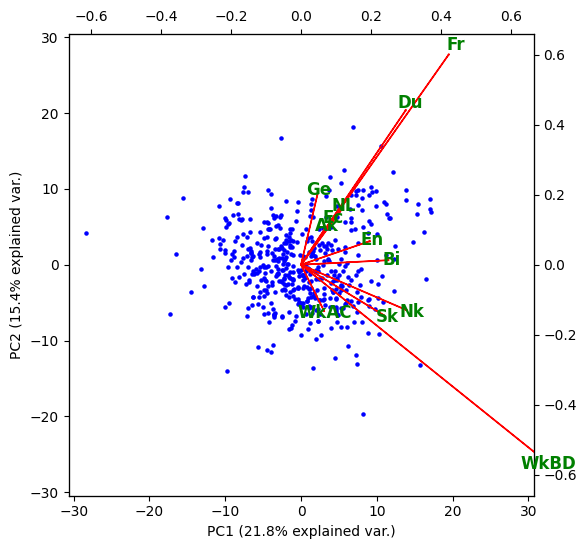

In [11]:
#produce biplot
biplot(dfScores, dfLoadings, pca)

In [12]:
K = 3  # Number of top contributing variables to show
# Print top K contributing variables for PC1 and PC2
for i in range(2):
    pc = 'PC' + str(i+1)
    print(f"\nTop {K} contributing variables for {pc}:")
    print(dfLoadings.loc[pc].abs().sort_values(ascending=False).head(K))        
plt.show()  



Top 3 contributing variables for PC1:
WkBD    0.674954
Fr      0.421238
Nk      0.300810
Name: PC1, dtype: float64

Top 3 contributing variables for PC2:
Fr      0.599453
WkBD    0.542139
Du      0.440278
Name: PC2, dtype: float64
